<h1><strong>Task 3: Basic Data Visualization (BDV)</strong></h1>

<p><strong>Description:</strong> Create basic plots and charts to visualize the distribution and relationships within the dataset.</p>

<h3><strong> Objectives:</strong></h3> 
<ul>
    <li>Create bar plots, line charts, and scatter plots.
    <li>Customize plot labels, titles, and legends.</li>
    <li>Export plots as images for reports.</li>
</ul>
<p>Tools: Python,matplotlib,seaborn.</p>

In [30]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent.parent.parent
sys.path.insert(0, str(PROJECT_ROOT))



CLEAN_DIR = PROJECT_ROOT / "data/cleaned_data"
FIG_DIR = PROJECT_ROOT / "outputs/figures/level_1/task_3"
FIG_DIR.mkdir(parents=True, exist_ok=True)
CLEAN_DIR.mkdir(parents=True, exist_ok=True)

print(f"Projet : {PROJECT_ROOT}")
print(f"Cleaned files : {len(list(CLEAN_DIR.rglob('*.csv')))}")

Projet : /home/broman/Downloads/CodVeva_internship/codveda_datanalysis
Cleaned files : 5


<h4>The dataset: Stock prices</h4>
<p>
    <h4><strong><li>Bar plots</li></strong></h4>
</p>

In [31]:
c_stock = pd.read_csv(CLEAN_DIR / "c_stock.csv")

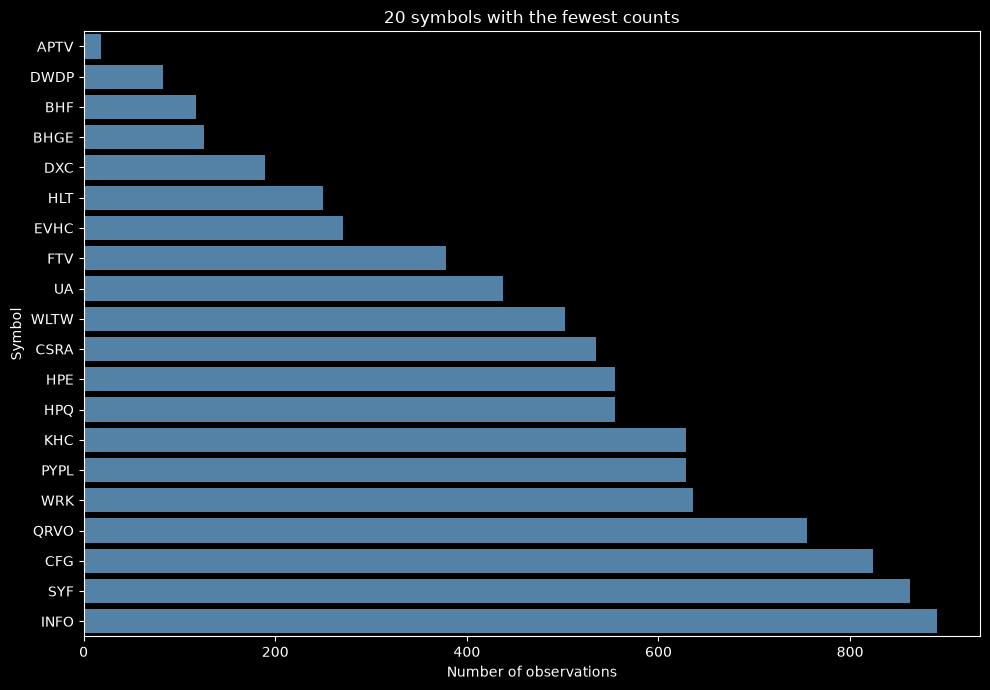

Figure exported : /home/broman/Downloads/CodVeva_internship/codveda_datanalysis/outputs/figures/level_1/task_3/smallest_20_symbols_by_count.png


In [34]:
# Bar plot for the 20 symbols with the fewest counts
last_symbols = c_stock["symbol"].value_counts().nsmallest(20)

plt.figure(figsize=(10, 7))
sns.barplot(x=last_symbols.values, y=last_symbols.index, color="steelblue")
plt.title("20 symbols with the fewest counts")
plt.xlabel("Number of observations")
plt.ylabel("Symbol")
plt.tight_layout()

output_path = FIG_DIR / "smallest_20_symbols_by_count.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Figure exported : {output_path}")

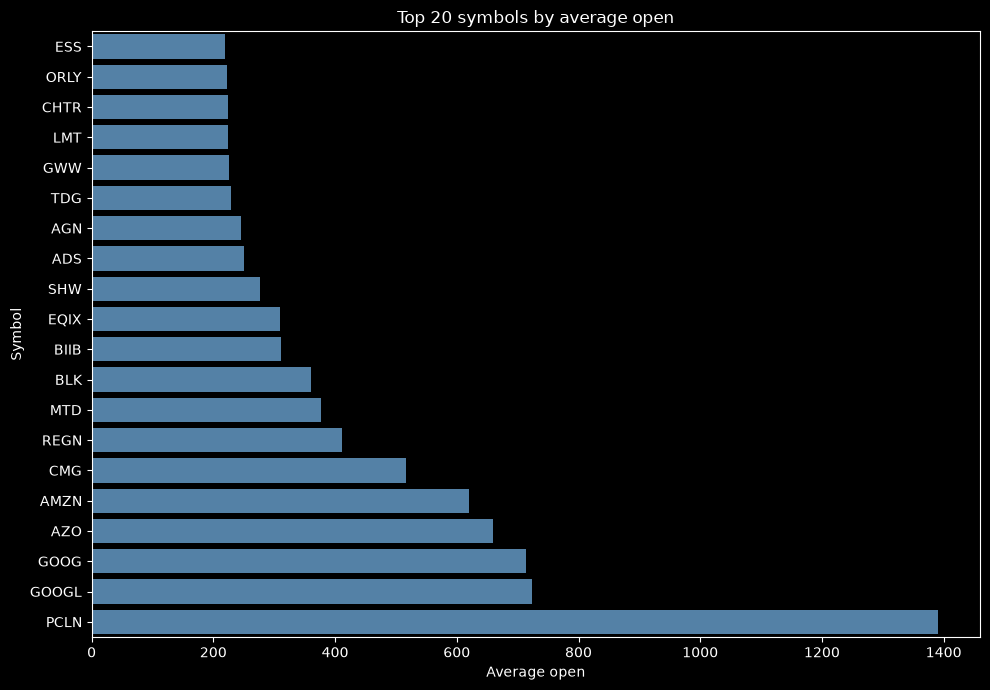

Figure exported : /home/broman/Downloads/CodVeva_internship/codveda_datanalysis/outputs/figures/level_1/task_3/smallest_20_symbols_by_average_open.png


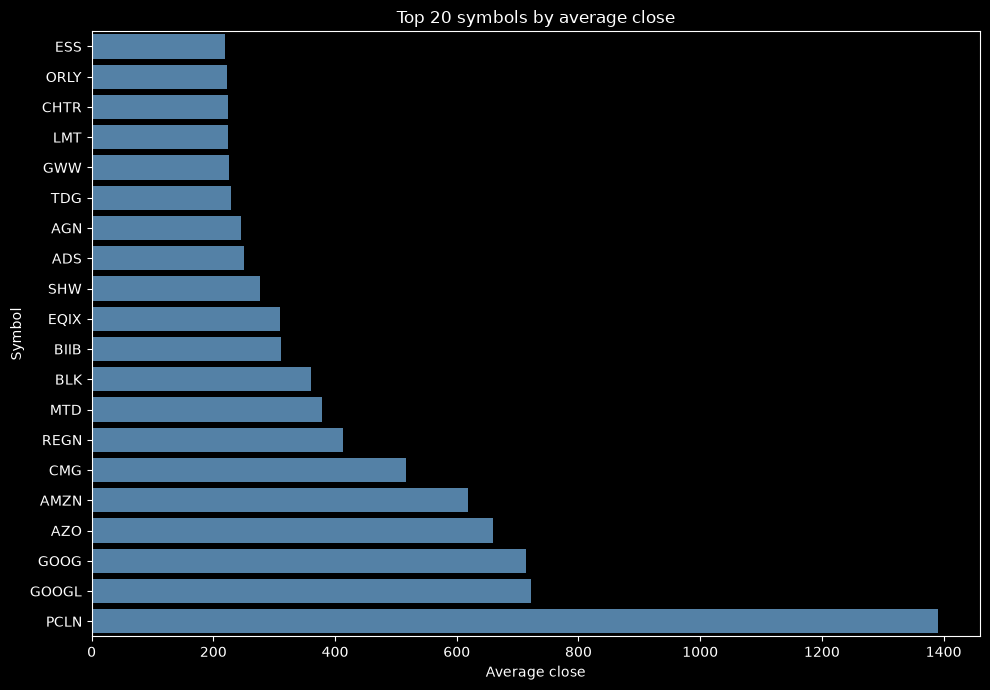

Figure exported : /home/broman/Downloads/CodVeva_internship/codveda_datanalysis/outputs/figures/level_1/task_3/smallest_20_symbols_by_average_close.png


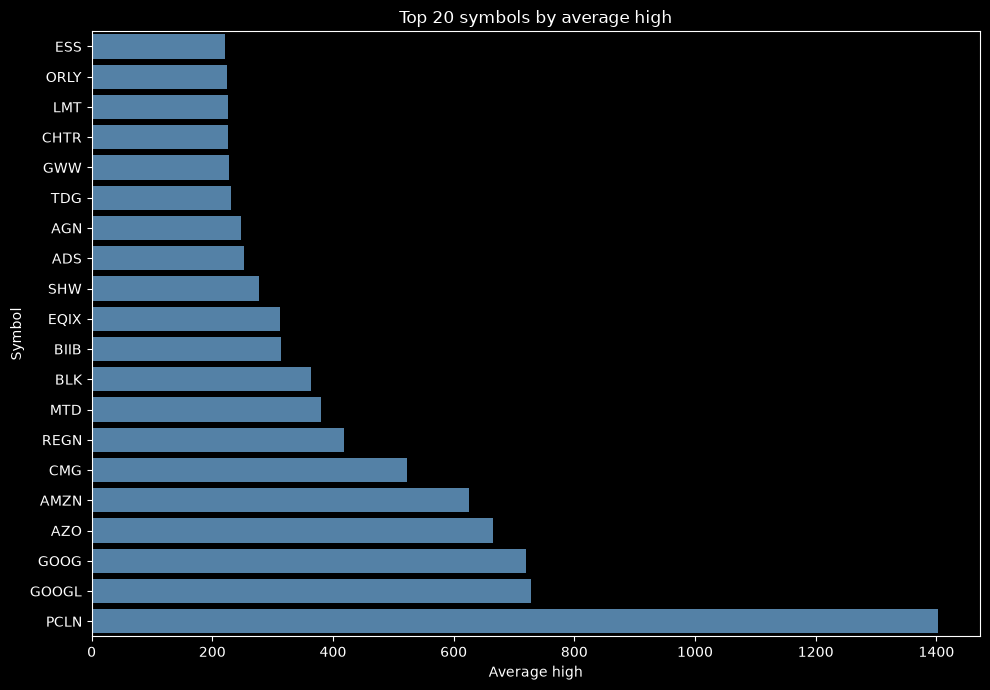

Figure exported : /home/broman/Downloads/CodVeva_internship/codveda_datanalysis/outputs/figures/level_1/task_3/smallest_20_symbols_by_average_high.png


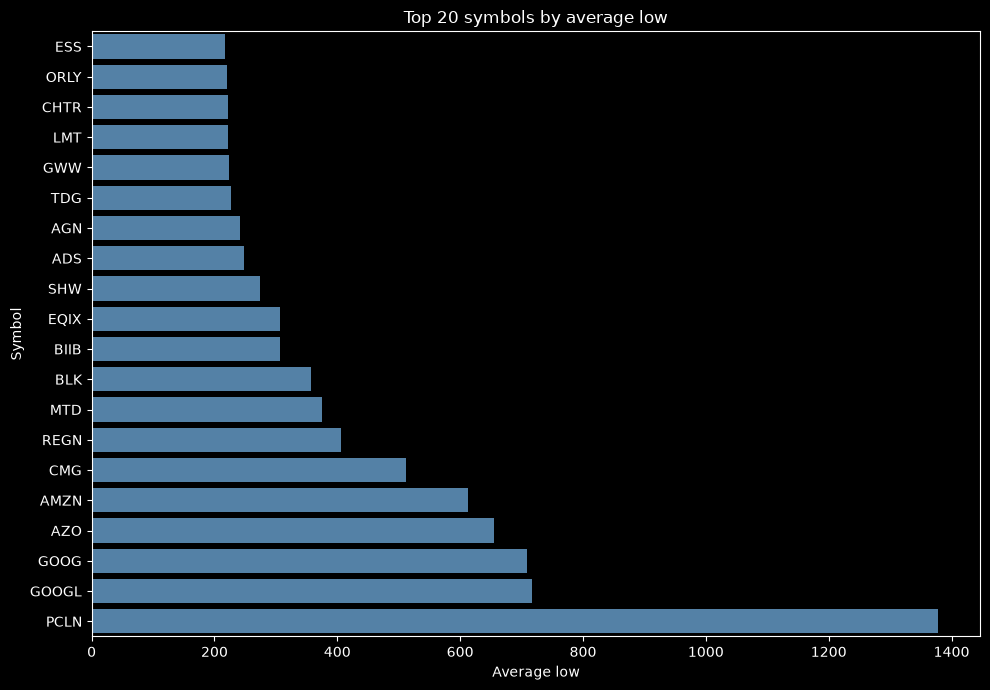

Figure exported : /home/broman/Downloads/CodVeva_internship/codveda_datanalysis/outputs/figures/level_1/task_3/smallest_20_symbols_by_average_low.png


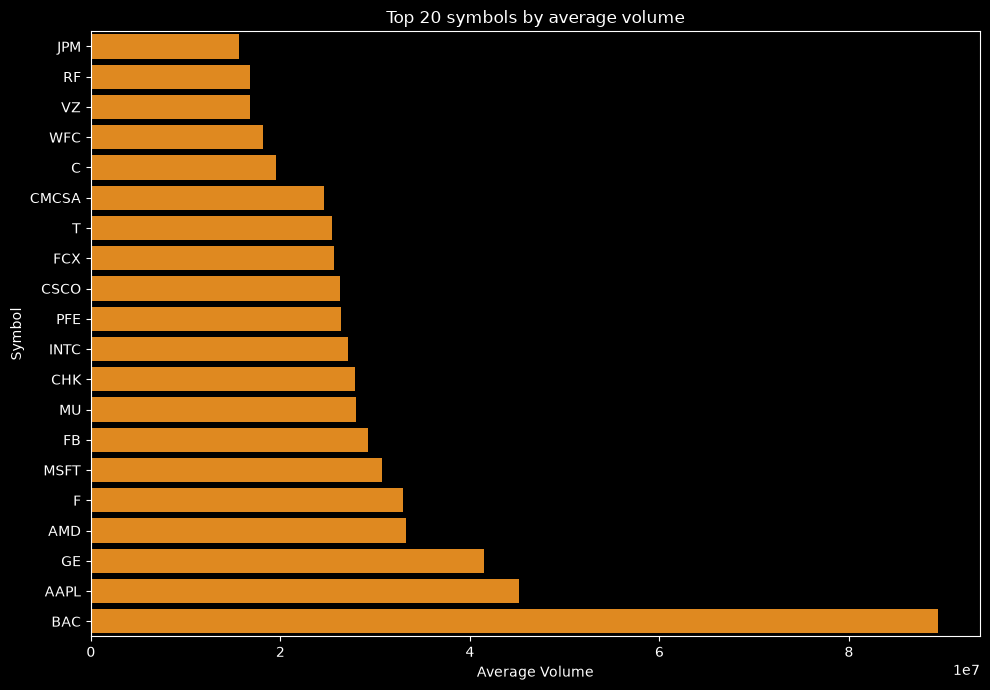

Figure exported : /home/broman/Downloads/CodVeva_internship/codveda_datanalysis/outputs/figures/level_1/task_3/smallest_20_symbols_by_average_volume.png


In [35]:
#Bar plot for the last symbols by the value of open, close, high, low
price_columns = ["open", "close", "high", "low"]

for column in price_columns:
    highest_symbols = (
        c_stock.groupby("symbol")[column]
        .mean()
        .nlargest(20)
        .sort_values()
    )

    plt.figure(figsize=(10, 7))
    sns.barplot(
        x=highest_symbols.values,
        y=highest_symbols.index,
        color="steelblue"
    )

    plt.title(f"Top 20 symbols by average {column}")
    plt.xlabel(f"Average {column}")
    plt.ylabel("Symbol")
    plt.tight_layout()
    output_path = FIG_DIR / f"smallest_20_symbols_by_average_{column}.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Figure exported : {output_path}")

highest_volume_symbols = (
    c_stock.groupby("symbol")["volume"]
    .mean()
    .nlargest(20)
    .sort_values()
)

plt.figure(figsize=(10, 7))
sns.barplot(
    x=highest_volume_symbols.values,
    y=highest_volume_symbols.index,
    color="darkorange"
)

plt.title("Top 20 symbols by average volume")
plt.xlabel("Average Volume")
plt.ylabel("Symbol")
plt.tight_layout() 
output_path = FIG_DIR / "smallest_20_symbols_by_average_volume.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Figure exported : {output_path}")

<p>
    <h4><strong><li>Line plots</li></strong></h4>
</p>

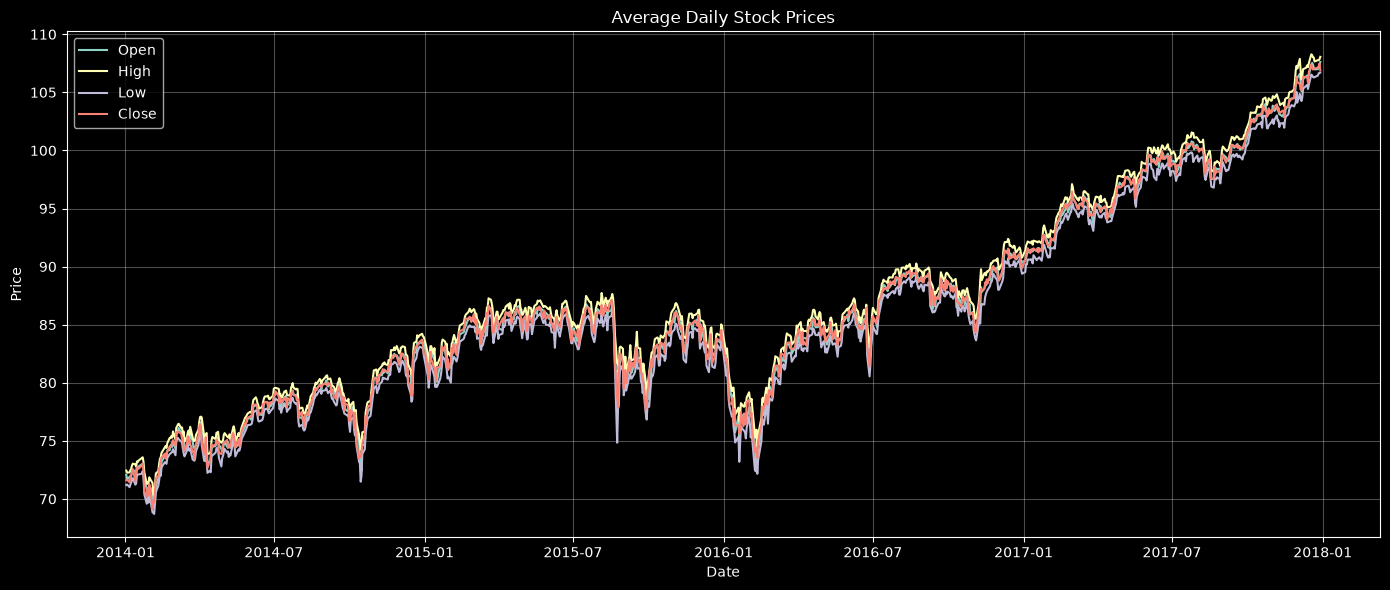

Figure exported : /home/broman/Downloads/CodVeva_internship/codveda_datanalysis/outputs/figures/level_1/task_3/average_daily_stock_prices.png


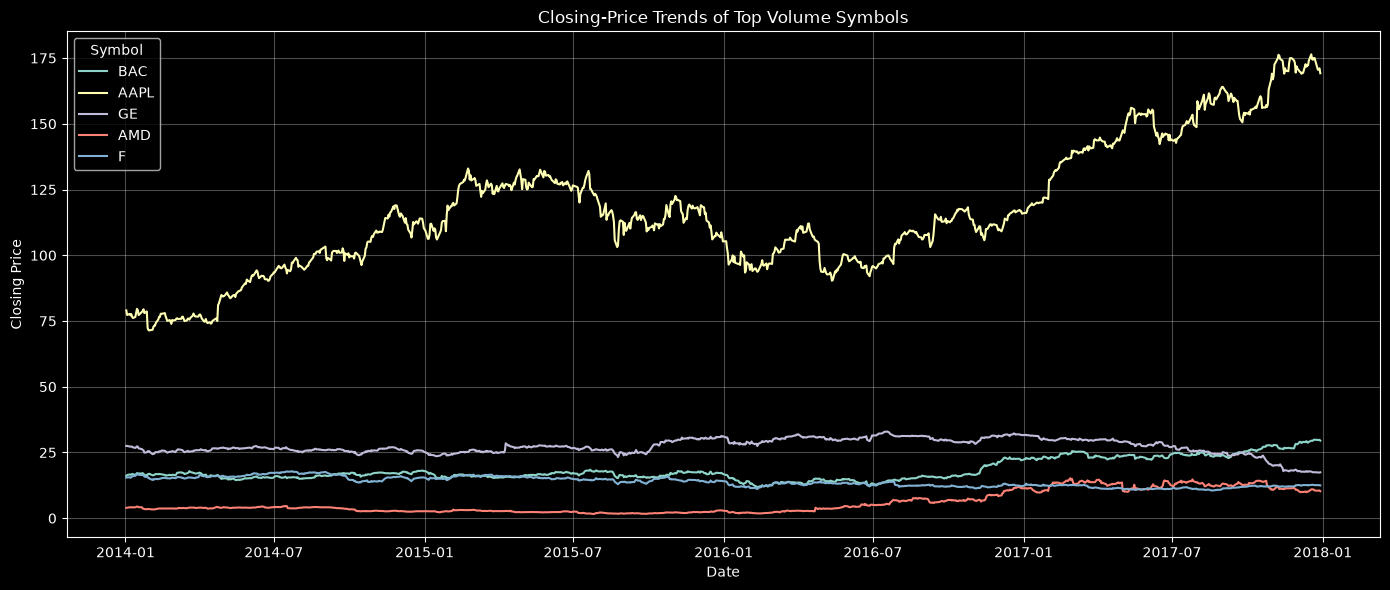

Figure exported : /home/broman/Downloads/CodVeva_internship/codveda_datanalysis/outputs/figures/level_1/task_3/closing_price_trends_top_volume_symbols.png


In [36]:
# Prepare daily aggregates for line plots
stock_daily = c_stock.copy()
stock_daily["date"] = pd.to_datetime(stock_daily["date"])

daily_prices = (
    stock_daily.groupby("date")[["open", "high", "low", "close"]]
    .mean()
)

# Average daily price trends
plt.figure(figsize=(14, 6))
for price_column in ["open", "high", "low", "close"]:
    plt.plot(
        daily_prices.index,
        daily_prices[price_column],
        label=price_column.capitalize()
    )

plt.title("Average Daily Stock Prices")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
output_path = FIG_DIR / "average_daily_stock_prices.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Figure exported : {output_path}")

# Closing-price trends for selected high-volume symbols
selected_symbols = highest_volume_symbols.nlargest(5).index

plt.figure(figsize=(14, 6))
for symbol in selected_symbols:
    symbol_data = (
        stock_daily[stock_daily["symbol"] == symbol]
        .groupby("date")["close"]
        .mean()
    )
    plt.plot(symbol_data.index, symbol_data, label=symbol)

plt.title("Closing-Price Trends of Top Volume Symbols")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend(title="Symbol")
plt.grid(alpha=0.3)
plt.tight_layout()
output_path = FIG_DIR / "closing_price_trends_top_volume_symbols.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"Figure exported : {output_path}")

<p>
    <h4><strong><li>Scatter plots</li></strong></h4>
</p>

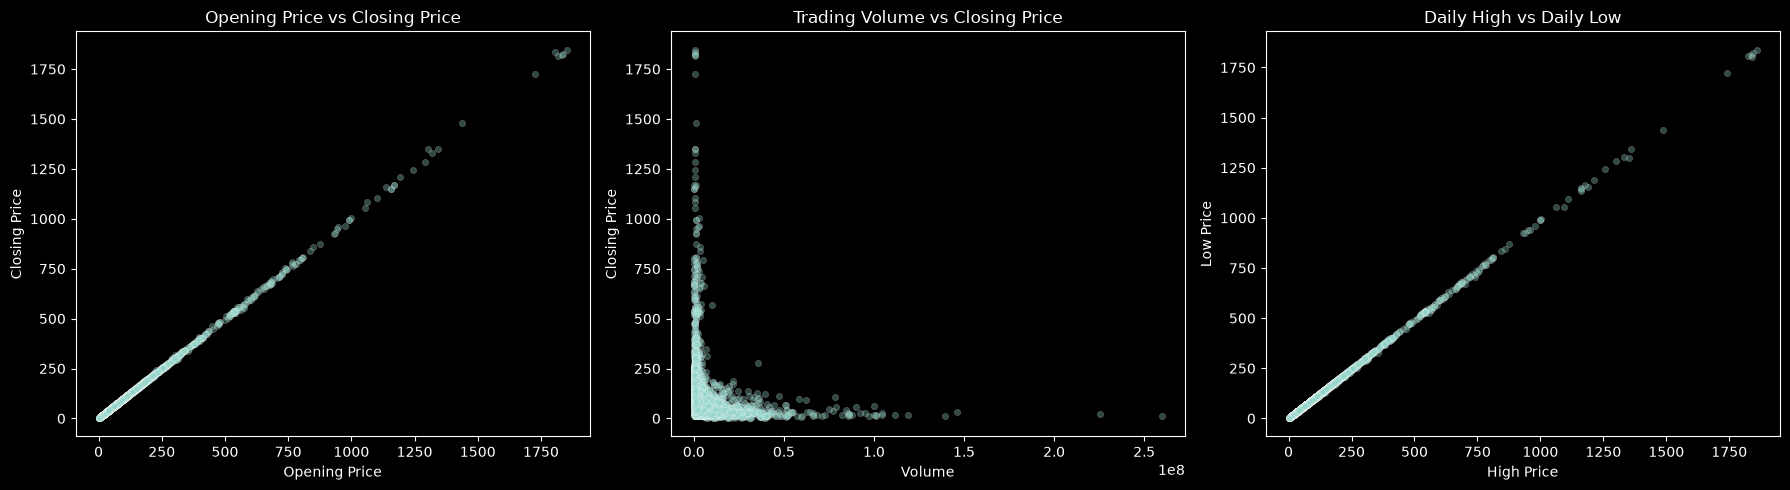

In [22]:
# Scatter plots showing relationships between stock price and volume variables and customize legends, titles, and axis labels
scatter_data = c_stock.sample(min(10_000, len(c_stock)), random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(
    data=scatter_data, x="open", y="close",
    alpha=0.35, s=20, ax=axes[0]
)
axes[0].set_title("Opening Price vs Closing Price")
axes[0].set_xlabel("Opening Price")
axes[0].set_ylabel("Closing Price")

sns.scatterplot(
    data=scatter_data, x="volume", y="close",
    alpha=0.35, s=20, ax=axes[1]
)
axes[1].set_title("Trading Volume vs Closing Price")
axes[1].set_xlabel("Volume")
axes[1].set_ylabel("Closing Price")

sns.scatterplot(
    data=scatter_data, x="high", y="low",
    alpha=0.35, s=20, ax=axes[2]
)
axes[2].set_title("Daily High vs Daily Low")
axes[2].set_xlabel("High Price")
axes[2].set_ylabel("Low Price")

plt.tight_layout()
plt.show()